# Environment Setup

In [1]:
import os

# Hadoop (must be set BEFORE Spark starts)
os.environ["HADOOP_HOME"] = r"C:\hadoop-3.0.0"
os.environ["hadoop.home.dir"] = r"C:\hadoop-3.0.0"
os.environ["PATH"] = os.environ["HADOOP_HOME"] + r"\bin;" + os.environ["PATH"]

In [2]:
import os

os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-11.0.30.7-hotspot"
os.environ["SPARK_HOME"] = r"C:\Users\HP\Downloads\spark-3.5.8-bin-hadoop3\spark-3.5.8-bin-hadoop3"
os.environ["PATH"] = os.environ["SPARK_HOME"] + r"\bin;" + os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

In [3]:
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.storagelevel import StorageLevel

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    VectorAssembler, StandardScaler, StringIndexer
)
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, GBTClassifier
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

import time
import numpy as np

# Initialize Spark Session

In [5]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Large-Scale-Knowledge-Discovery-BagOfWords-PySpark")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.executor.memory", "4g")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

spark

# Data Ingestion and Storage Design

## Data Ingestion

In [9]:
from pyspark.sql import functions as F

In [11]:
raw_df = spark.read.text(
    r"E:\Datasets\bag+of+words\docword.enron.txt\docword.enron.txt"
)

In [12]:
data_df = (
    raw_df
    .withColumn("row_id", F.monotonically_increasing_id())
    .filter(F.col("row_id") >= 3)
    .drop("row_id")
)

In [13]:
bow_df = (
    data_df
    .select(
        F.split(F.col("value"), " ").getItem(0).cast("int").alias("doc_id"),
        F.split(F.col("value"), " ").getItem(1).cast("int").alias("word_id"),
        F.split(F.col("value"), " ").getItem(2).cast("int").alias("count"),
    )
)

In [14]:
bow_df.show(5)

+------+-------+-----+
|doc_id|word_id|count|
+------+-------+-----+
|     1|    118|    1|
|     1|    285|    1|
|     1|   1229|    1|
|     1|   1688|    1|
|     1|   2068|    1|
+------+-------+-----+
only showing top 5 rows



# Data Validation at Ingestion

In [15]:
from pyspark.sql.functions import col

In [16]:
# Null checks
bow_df.filter(
    col("doc_id").isNull() |
    col("word_id").isNull() |
    col("count").isNull()
).count()

0

In [17]:
# Invalid value checks
bow_df.filter(
    (col("doc_id") <= 0) |
    (col("word_id") <= 0) |
    (col("count") <= 0)
).count()

0

In [18]:
# Duplicate check
bow_df.count(), bow_df.dropDuplicates().count()

(3710420, 3710420)

# Partitioning Strategy

In [19]:
bow_df = bow_df.repartition(200, "doc_id")

# Distributed Data Processing Pipeline

## Memory Management Strategy

In [21]:
bow_df.persist(StorageLevel.MEMORY_AND_DISK)

DataFrame[doc_id: int, word_id: int, count: int]

## Vocabulary Ingestion (Broadcast Join)

In [22]:
vocab_df = (
    spark.read.text(r"E:\Datasets\bag+of+words\vocab.enron.txt")
    .withColumnRenamed("value", "word")
    .withColumn("word_id", F.monotonically_increasing_id() + 1)
)

In [23]:
from pyspark.sql.functions import broadcast

In [24]:
bow_with_words = bow_df.join(
    broadcast(vocab_df),
    on="word_id",
    how="inner"
)

## Error Handling & Lineage

In [25]:
try:
    bow_with_words.count()
except Exception as e:
    print("Pipeline failure:", e)

# Data Cleaning & Feature Preparation

## Remove Extreme Outliers (Very Large Counts)

In [26]:
quantiles = bow_df.approxQuantile("count", [0.99], 0.01)
upper_bound = quantiles[0]

clean_df = bow_df.filter(col("count") <= upper_bound)

## Document Length Computation

In [27]:
doc_length_df = (
    clean_df
    .groupBy("doc_id")
    .agg(F.sum("count").alias("doc_length"))
)

# Exploratory Data Analysis

In [28]:
import matplotlib.pyplot as plt

## Plot 1: Distribution of Document Lengths

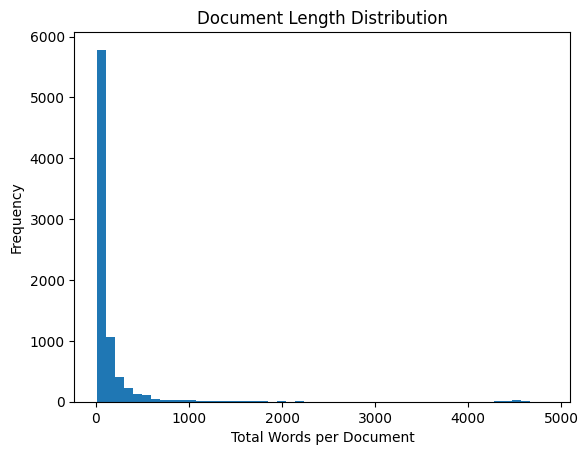

In [29]:
doc_lengths_pd = doc_length_df.sample(fraction=0.2, seed=42).toPandas()

plt.hist(doc_lengths_pd["doc_length"], bins=50)
plt.title("Document Length Distribution")
plt.xlabel("Total Words per Document")
plt.ylabel("Frequency")
plt.show()

## Plot 2: Top 20 Most Frequent Words

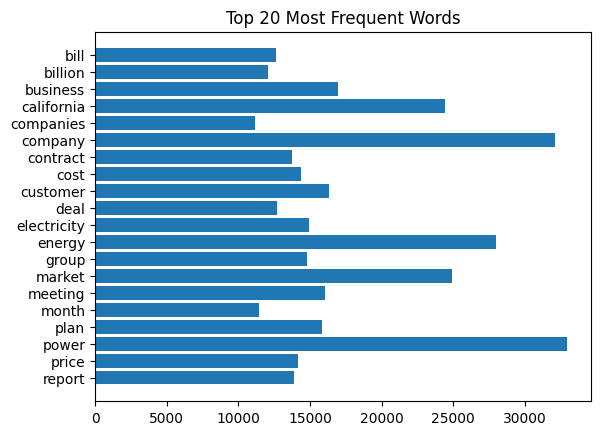

In [30]:
top_words_pd = (
    clean_df.groupBy("word_id")
    .agg(F.sum("count").alias("freq"))
    .orderBy(F.desc("freq"))
    .limit(20)
    .join(vocab_df, "word_id")
    .toPandas()
)

plt.barh(top_words_pd["word"], top_words_pd["freq"])
plt.title("Top 20 Most Frequent Words")
plt.gca().invert_yaxis()
plt.show()

## Plot 3: Word Frequency Distribution (Zipf-like)

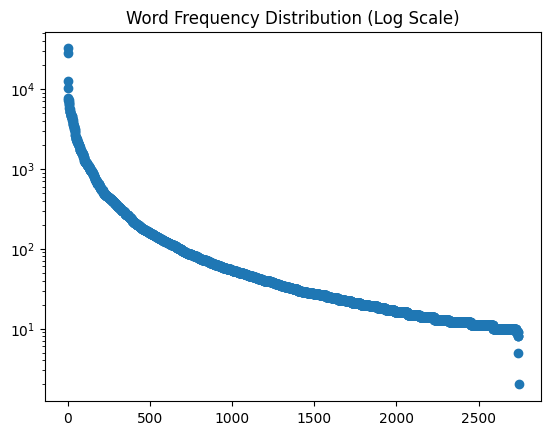

In [31]:
word_freq_pd = (
    clean_df.groupBy("word_id")
    .agg(F.sum("count").alias("freq"))
    .sample(fraction=0.1, seed=42)
    .toPandas()
)

plt.scatter(range(len(word_freq_pd)), sorted(word_freq_pd["freq"], reverse=True))
plt.yscale("log")
plt.title("Word Frequency Distribution (Log Scale)")
plt.show()

## Plot 4: Sparsity per Document

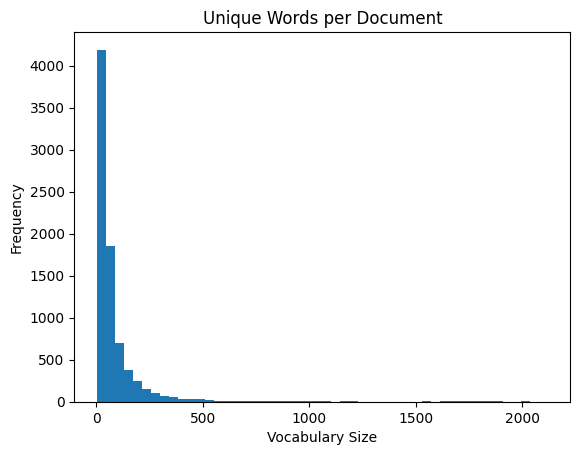

In [32]:
doc_sparsity_pd = (
    clean_df.groupBy("doc_id")
    .count()
    .sample(fraction=0.2, seed=42)
    .toPandas()
)

plt.hist(doc_sparsity_pd["count"], bins=50)
plt.title("Unique Words per Document")
plt.xlabel("Vocabulary Size")
plt.ylabel("Frequency")
plt.show()

## Plot 5: Count Value Distribution

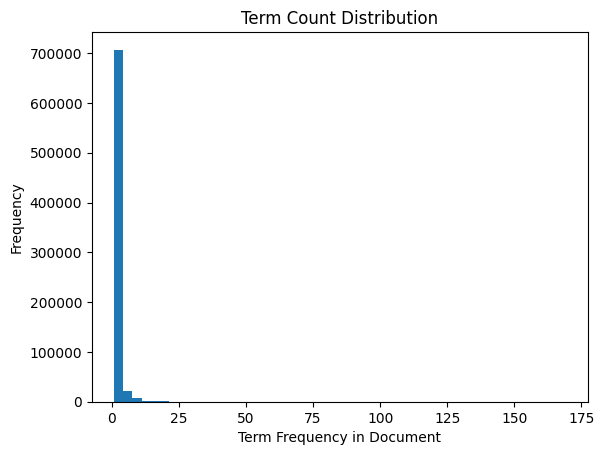

In [33]:
count_pd = clean_df.select("count").sample(fraction=0.2, seed=42).toPandas()

plt.hist(count_pd["count"], bins=50)
plt.title("Term Count Distribution")
plt.xlabel("Term Frequency in Document")
plt.ylabel("Frequency")
plt.show()

# Cleanup

In [34]:
bow_df.unpersist()
clean_df.unpersist()

DataFrame[doc_id: int, word_id: int, count: int]

# Document Vectorization (Feature Engineering)

## TF Vectorization (Sparse, Scalable)

In [35]:
from pyspark.sql import functions as F

In [36]:
doc_terms_df = (
    clean_df
    .groupBy("doc_id")
    .agg(
        F.collect_list(
            F.struct("word_id", "count")
        ).alias("terms")
    )
)

## Custom Transformer: Bag-of-Words → Sparse Vector

In [37]:
from pyspark.ml import Transformer
from pyspark.ml.linalg import SparseVector
from pyspark.sql.types import StructType, StructField

In [38]:
class SparseVectorTransformer(Transformer):
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size

    def _transform(self, df):
        def to_sparse(term_list):
            indices = [t["word_id"] - 1 for t in term_list]
            values = [t["count"] for t in term_list]
            return SparseVector(self.vocab_size, indices, values)

        to_sparse_udf = F.udf(to_sparse)

        return df.withColumn(
            "features",
            to_sparse_udf(F.col("terms"))
        )

In [39]:
vocab_size = 28102  # Enron
vectorizer = SparseVectorTransformer(vocab_size)
vector_df = vectorizer.transform(doc_terms_df).select("doc_id", "features")

In [40]:
vector_df.persist()

DataFrame[doc_id: int, features: string]

# MLlib Clustering Models (Unsupervised)

## KMeans Clustering (Geometric Similarity)

In [52]:
from pyspark.sql import functions as F

In [53]:
doc_terms_df = (
    clean_df
    .groupBy("doc_id", "word_id")
    .agg(F.sum("count").alias("count"))
)

In [54]:
doc_terms_df = (
    doc_terms_df
    .groupBy("doc_id")
    .agg(
        F.collect_list(
            F.struct("word_id", "count")
        ).alias("terms")
    )
)

In [55]:
from pyspark.ml import Transformer
from pyspark.ml.linalg import SparseVector, VectorUDT

In [56]:
class SparseVectorTransformer(Transformer):
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size

    def _transform(self, df):

        def to_sparse(term_list):
            # sort by word_id
            sorted_terms = sorted(term_list, key=lambda x: x["word_id"])

            indices = [int(t["word_id"]) - 1 for t in sorted_terms]
            values = [float(t["count"]) for t in sorted_terms]

            return SparseVector(self.vocab_size, indices, values)

        to_sparse_udf = F.udf(to_sparse, VectorUDT())

        return df.withColumn(
            "features",
            to_sparse_udf(F.col("terms"))
        )

In [57]:
vocab_size = 28102

vectorizer = SparseVectorTransformer(vocab_size)

vector_df = (
    vectorizer
    .transform(doc_terms_df)
    .select("doc_id", "features")
)

In [58]:
vector_df.printSchema()
vector_df.select("features").show(3, truncate=False)

root
 |-- doc_id: integer (nullable = true)
 |-- features: vector (nullable = true)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [59]:
from pyspark.ml.clustering import KMeans

In [60]:
kmeans = KMeans(
    k=10,
    seed=42,
    featuresCol="features",
    predictionCol="kmeans_cluster"
)

In [61]:
kmeans_model = kmeans.fit(vector_df)
kmeans_result = kmeans_model.transform(vector_df)

## Latent Dirichlet Allocation (Topic Modeling)

In [62]:
from pyspark.ml.clustering import LDA

In [63]:
lda = LDA(
    k=10,
    maxIter=10,
    featuresCol="features"
)

In [64]:
lda_model = lda.fit(vector_df)
lda_topics = lda_model.transform(vector_df)

In [65]:
lda_topics.select("doc_id", "topicDistribution").show(5, truncate=False)

+------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|doc_id|topicDistribution                                                                                                                                                                                                     |
+------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|148   |[6.587803437091988E-4,6.405843212255086E-4,6.406380869259625E-4,6.346311188374238E-4,7.77860381903822E-4,6.343107970369485E-4,0.9940106639653868,7.062209381947033E-4,6.607189330518753E-4,6.355911137276484E-4]      |
|463   |[3.9688365846768744E-4,3.859460682304046E-4,3.8594880974235807E-4,3.823509284520329E-4,4.6860927

## Bisecting KMeans (Hierarchical Structure)

In [83]:
from pyspark.sql.functions import udf, col
from pyspark.sql.types import BooleanType

In [84]:
def has_nonzero(v):
    return v is not None and v.numNonzeros() > 0

In [85]:
has_nonzero_udf = udf(has_nonzero, BooleanType())

In [86]:
vector_df_clean = (
    vector_df
    .filter(col("features").isNotNull())
    .filter(has_nonzero_udf(col("features")))
)

In [87]:
vector_df_clean.persist()

DataFrame[doc_id: int, features: vector]

In [88]:
vector_df_clean.count()

39861

In [89]:
from pyspark.ml.clustering import BisectingKMeans

In [90]:
bkm = BisectingKMeans(
    k=10,
    seed=42,
    featuresCol="features",
    predictionCol="bkm_cluster",
    minDivisibleClusterSize=5.0
)

In [91]:
bkm_model = bkm.fit(vector_df_clean)
bkm_result = bkm_model.transform(vector_df_clean)

In [95]:
bkm_result.groupBy("bkm_cluster").count().show()

+-----------+-----+
|bkm_cluster|count|
+-----------+-----+
|          1| 8682|
|          3|  235|
|          5|  219|
|          9|  172|
|          4| 1395|
|          7|   69|
|          2| 4415|
|          0|24412|
|          8|  170|
|          6|   92|
+-----------+-----+



# Pseudo-Label Generation

## Use KMeans Clusters as Pseudo-Labels

In [93]:
pseudo_labeled_df = (
    kmeans_result
    .select("doc_id", "features", F.col("kmeans_cluster").alias("label"))
)

# Classification on Pseudo-Labels (Supervised ML)

## Train / Validation Split

In [94]:
train_df, test_df = pseudo_labeled_df.randomSplit([0.8, 0.2], seed=42)

## MLlib Classifiers

## Logistic Regression

In [96]:
from pyspark.ml.classification import LogisticRegression

In [97]:
lr = LogisticRegression(
    maxIter=20,
    regParam=0.1,
    elasticNetParam=0.0
)

In [98]:
lr_model = lr.fit(train_df)
lr_preds = lr_model.transform(test_df)

## Random Forest

In [99]:
from pyspark.ml.classification import RandomForestClassifier

In [100]:
rf = RandomForestClassifier(
    numTrees=50,
    maxDepth=10
)

In [101]:
rf_model = rf.fit(train_df)
rf_preds = rf_model.transform(test_df)

# Distributed Evaluation Metrics

## Accuracy (Cluster Reproduction)

In [102]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [103]:
evaluator = MulticlassClassificationEvaluator(
    metricName="accuracy"
)

In [104]:
lr_acc = evaluator.evaluate(lr_preds)
rf_acc = evaluator.evaluate(rf_preds)

lr_acc, rf_acc

(0.9896817503729488, 0.9781203381402287)

# Prepare Training Data

In [105]:
from pyspark.sql.functions import col

In [106]:
pseudo_labeled_df = (
    kmeans_result
    .select("doc_id", "features", col("kmeans_cluster").alias("label"))
)

# Train / Validation / Test Split (Distributed-Safe)

In [107]:
train_df, test_df = pseudo_labeled_df.randomSplit([0.8, 0.2], seed=42)

In [108]:
train_df = train_df.repartition("label")

# Distributed Training & Hyperparameter Tuning

## Logistic Regression + CrossValidator

In [109]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [110]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20
)

In [111]:
paramGrid_lr = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0, 0.5])
    .build()
)

In [112]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

In [114]:
cv_lr = CrossValidator(
    estimator=lr,
    estimatorParamMaps=paramGrid_lr,
    evaluator=evaluator,
    numFolds=3,
    parallelism=4   
)

In [116]:
train_df = train_df.localCheckpoint(eager=True)

In [117]:
cv_lr_model = cv_lr.fit(train_df)
lr_preds = cv_lr_model.transform(test_df)

## Random Forest + CrossValidator

In [118]:
from pyspark.ml.classification import RandomForestClassifier

In [119]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label"
)

In [120]:
paramGrid_rf = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [30, 50])
    .addGrid(rf.maxDepth, [5, 10])
    .build()
)

In [121]:
cv_rf = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid_rf,
    evaluator=evaluator,
    numFolds=3,
    parallelism=4
)

In [122]:
cv_rf_model = cv_rf.fit(train_df)
rf_preds = cv_rf_model.transform(test_df)

# Evaluation Metrics (Distributed)

In [123]:
lr_acc = evaluator.evaluate(lr_preds)
rf_acc = evaluator.evaluate(rf_preds)

print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.9896817503729488
Random Forest Accuracy: 0.9789905519641969


# Bootstrap Confidence Intervals (Statistical Significance)

In [124]:
import numpy as np

In [125]:
test_pd = rf_preds.select("label", "prediction").toPandas()

In [126]:
def bootstrap_accuracy(data, n=100):
    scores = []
    for _ in range(n):
        sample = data.sample(frac=1, replace=True)
        scores.append((sample["label"] == sample["prediction"]).mean())
    return np.percentile(scores, [2.5, 97.5])

In [127]:
ci_rf = bootstrap_accuracy(test_pd)
ci_lr = bootstrap_accuracy(lr_preds.select("label", "prediction").toPandas())

# Model Comparison Plot

In [128]:
import matplotlib.pyplot as plt

In [129]:
models = ["Logistic Regression", "Random Forest"]
scores = [lr_acc, rf_acc]

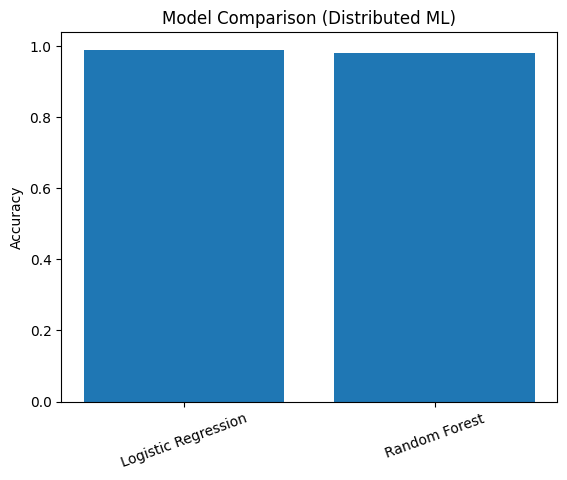

In [130]:
plt.figure()
plt.bar(models, scores)
plt.ylabel("Accuracy")
plt.title("Model Comparison (Distributed ML)")
plt.xticks(rotation=20)
plt.show()

# Scalability Analysis

In [131]:
import time

In [132]:
def measure_runtime(partitions):
    df = train_df.repartition(partitions)
    start = time.time()
    lr.fit(df)
    return time.time() - start

In [133]:
times = []
parts = [50, 100, 200]

for p in parts:
    times.append(measure_runtime(p))

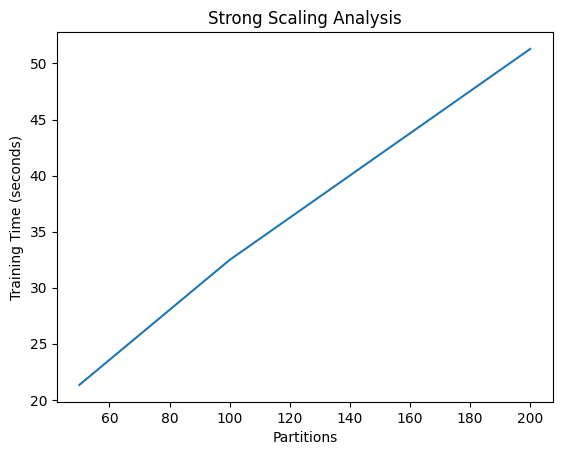

In [134]:
plt.figure()
plt.plot(parts, times)
plt.xlabel("Partitions")
plt.ylabel("Training Time (seconds)")
plt.title("Strong Scaling Analysis")
plt.show()

# Weak Scaling (Increase Data Size)

In [135]:
fractions = [0.25, 0.5, 1.0]
weak_times = []

for f in fractions:
    subset = train_df.sample(fraction=f)
    start = time.time()
    lr.fit(subset)
    weak_times.append(time.time() - start)

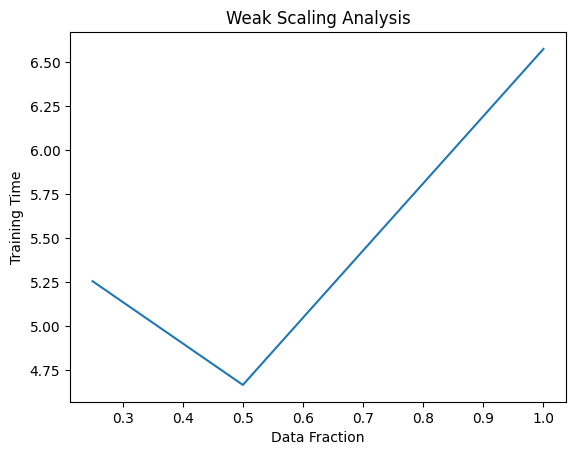

In [136]:
plt.figure()
plt.plot(fractions, weak_times)
plt.xlabel("Data Fraction")
plt.ylabel("Training Time")
plt.title("Weak Scaling Analysis")
plt.show()

# Resource Allocation Justification

# Cost–Performance Tradeoff

In [139]:
cost_efficiency = [t / p for t, p in zip(times, parts)]